In [10]:
import os
import glob

import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt

import rasterio as rio

lf_dir = '/home/rpdemilt/SIG/fuels/eo-fuels-extrapolation/data/FBFM40/LF2024_FBFM40_250_CONUS/CSV_Data/LF24_F40_250.csv'

FM40_LABELS = [
    91, 92, 93, 98, 99,
    101, 102, 103, 104, 105, 106, 107, 108, 109,
    121, 122, 123, 124,
    141, 142, 143, 144, 145, 146, 147, 148, 149,
    161, 162, 163, 164, 165,
    181, 182, 183, 184, 185, 186, 187, 188, 189,
    201, 202, 203, 204,
]

fuel_groups = {
    'NB':[91, 92, 93, 98, 99],
    'GR':[101, 102, 103, 104, 105, 106, 107, 108, 109],
    'GS':[121, 122, 123, 124],
    'SH':[141, 142, 143, 144, 145, 146, 147, 148, 149],
    'TU':[161, 162, 163, 164, 165],
    'TL':[181, 182, 183, 184, 185, 186, 187, 188, 189],
    'SB':[201, 202, 203, 204]
    }


dropped_labels = [91,92,93,98,99]

valid_labels = [label for label in FM40_LABELS if all([label != drop for drop in dropped_labels])]

def make_label_encoder(valid_labels):
    label_map = dict(zip(valid_labels,np.arange(len(valid_labels))))
    label_map[-1] = -1
    
    inv_label_map = {v:k for k,v in label_map.items()}

    def encode_fn(x):
        return label_map[x]
    
    def decode_fn(x):
        return inv_label_map[x]
    
    label_encode = np.vectorize(encode_fn)
    label_decode = np.vectorize(decode_fn)
    
    return label_encode, label_decode

label_encoder, label_decoder = make_label_encoder(valid_labels)

lfdf = pd.read_csv(lf_dir)
lf_colors = dict(zip(lfdf['VALUE'],zip(lfdf['R'],lfdf['G'],lfdf['B'])))

In [3]:
pyromes = [26,4,45]

results = {}

for pyrome in pyromes:
    exp_name = f'p{pyrome}-comparisons'
    results_file = f'./results/{exp_name}/results.csv'
    results_df = pd.read_csv(results_file)
    results[pyrome] = results_df

In [11]:
inference_results_dir = './results/p26-inference/'
target_pyrome = 26

tilenums = glob.glob(os.path.join(inference_results_dir,str(target_pyrome),'*'))

t_0 = tilenums[4]

pred_src = rio.open(os.path.join(t_0,'pred_tile.tif'))
label_src = rio.open(os.path.join(t_0,'label_tile.tif'))
topk_src = rio.open(os.path.join(t_0,'topk_tile.tif'))

pred_tile = label_decoder(pred_src.read())
label_tile = label_decoder(label_src.read())
topk_tile = label_decoder(topk_src.read())

n_top_k = topk_tile.shape[0]

In [13]:
pred_tile.shape

(1, 1760, 1760)

Text(0.5, 1.0, 'FBFM40 Label 00372')

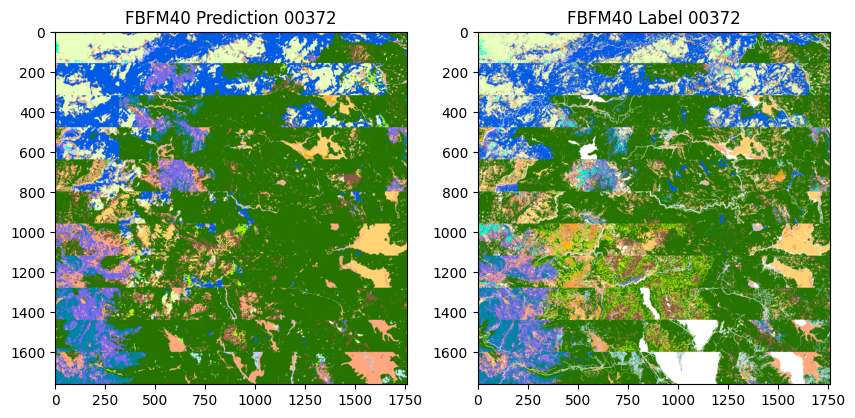

In [15]:
label_tile[0].shape

viz_label_tile = label_tile
viz_label_tile[viz_label_tile == -1] = -9999

lf_cmap = np.vectorize(lf_colors.get)
colored_preds = np.stack(lf_cmap(pred_tile[0]),axis=2)
colored_labels = np.stack(lf_cmap(label_tile[0]),axis=2)

fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(10,10))

axs[0].imshow(colored_preds)
axs[0].set_title(f'FBFM40 Prediction {t_0.split('/')[-1]}')

axs[1].imshow(colored_labels)
axs[1].set_title(f'FBFM40 Label {t_0.split('/')[-1]}')

In [8]:
# Q: what is the relative divergence of certain baselines in a tile such as fireline intensity or base spread rate?
from pprint import pprint
from pyretechnics.fuel_models import get_fuel_model, moisturize
from pyretechnics.surface_fire import calc_surface_fire_behavior_no_wind_no_slope


#Wildland Fuel Moisture Values at varying severities, selected by Kayla
low_severity = (
    0.07, # dead_1hr
    0.10, # dead_10hr
    0.15, # dead_100hr
    0.00, # dead_herbaceous (will be set by moisturize for dynamic fuel models)
    0.90, # live_herbaceous
    1.20  # live_woody
)

moderate_severity = (
    0.05, # dead_1hr
    0.07, # dead_10hr
    0.10, # dead_100hr
    0.00, # dead_herbaceous (will be set by moisturize for dynamic fuel models)
    0.70, # live_herbaceous
    1.00  # live_woody
)

high_severity = (
    0.03, # dead_1hr
    0.04, # dead_10hr
    0.05, # dead_100hr
    0.00, # dead_herbaceous (will be set by moisturize for dynamic fuel models)
    0.20, # live_herbaceous
    0.80  # live_woody
)

vals_present = np.unique(label_tile)